In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

DATA_PATH = Path("data/rent.csv")
TARGET_CATEGORIES = ["Appartements", "Maisons et Villas"]
REMOVE_TOP_3_PERCENT_OUTLIERS = True

df = pd.read_csv(DATA_PATH)
df = df[df["category"].isin(TARGET_CATEGORIES)].copy()

if REMOVE_TOP_3_PERCENT_OUTLIERS:
    p97 = df["price"].quantile(0.97)
    df = df[df["price"] <= p97].copy()

df = df.drop_duplicates().reset_index(drop=True)

feature_columns = ["room_count", "bathroom_count", "size", "city", "region", "category"]
X = df[feature_columns]
y = np.log1p(df["price"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    )

categorical_features = ["city", "region", "category"]
numeric_features = ["room_count", "bathroom_count", "size"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
    ]
)

model = Pipeline(
    [
        ("preprocess", preprocess),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)
actual = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)
r2 = r2_score(actual, pred)

print("Dataset used:", DATA_PATH)
print("Rows used:", len(df))
print("Top 3% outliers removed:", REMOVE_TOP_3_PERCENT_OUTLIERS)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Dataset used: data/rent.csv
Rows used: 6412
Top 3% outliers removed: True
RMSE: 601.7189578906238
MAE: 394.39015673663835
R2: 0.381356950936087


In [6]:
from pathlib import Path
import joblib

MODEL_OUTPUT_PATH = Path("models/rent_model.joblib")
# MODEL_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# joblib.dump(model, MODEL_OUTPUT_PATH)
# print(f"Model saved to: {MODEL_OUTPUT_PATH.resolve()}")

Loaded model from: models/rent_model.joblib

Evaluation Metrics (Loaded Model):


,Metric,Value
0,MAE,394.390157
1,MSE,362065.704285
2,RMSE,601.718958
3,R2,0.381357
4,Adjusted R2,0.378448
5,MAPE (%),602.923789
6,Median AE,240.610738
7,Explained Variance,0.417875
8,CV RMSE Mean (log-space),1.075479
9,CV RMSE Std (log-space),0.050424


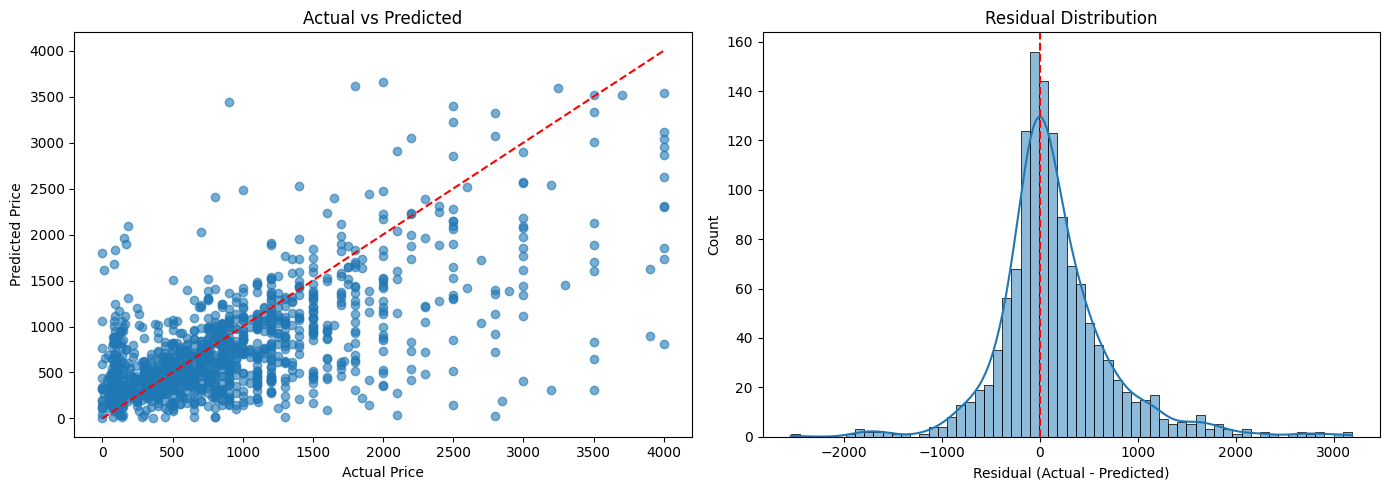

In [7]:
from sklearn.metrics import (
    explained_variance_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

# Load saved rent model artifact
loaded_model = joblib.load(MODEL_OUTPUT_PATH)

# Evaluate loaded model on holdout set
pred_log_loaded = loaded_model.predict(X_test)
pred_loaded = np.expm1(pred_log_loaded)
actual = np.expm1(y_test)

mse = mean_squared_error(actual, pred_loaded)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, pred_loaded)
r2 = r2_score(actual, pred_loaded)
medae = median_absolute_error(actual, pred_loaded)
ev = explained_variance_score(actual, pred_loaded)

epsilon = 1e-8
mape = np.mean(np.abs((actual - pred_loaded) / np.maximum(np.abs(actual), epsilon))) * 100

n = len(actual)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan

# Cross-validation RMSE on original feature space
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = -cross_val_score(
    loaded_model,
    X,
    y,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "Adjusted R2",
            "MAPE (%)",
            "Median AE",
            "Explained Variance",
            "CV RMSE Mean (log-space)",
            "CV RMSE Std (log-space)",
        ],
        "Value": [
            mae,
            mse,
            rmse,
            r2,
            adj_r2,
            mape,
            medae,
            ev,
            cv_rmse_scores.mean(),
            cv_rmse_scores.std(),
        ],
    }
)

print("Loaded model from:", MODEL_OUTPUT_PATH)
print("\nEvaluation Metrics (Loaded Model):")
display(metrics_df)

# Evaluation plots
residuals = actual - pred_loaded
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(actual, pred_loaded, alpha=0.6)
axes[0].plot([actual.min(), actual.max()], [actual.min(), actual.max()], "r--")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Actual vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()